In [14]:
# Install required packages (if not already installed)
!pip install -q scikit-learn xgboost pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
import joblib
import warnings
import re
import random
from collections import Counter
from typing import Dict, List, Tuple, Any
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# IMPORTANT: Set which discipline's subfields to classify
DISCIPLINE = 'IS'  # Change to 'IS' or 'IT' for other classifiers

print(f"Setup complete! Training {DISCIPLINE} subfield classifier")

Setup complete! Training IS subfield classifier


In [15]:
# Mount Google Drive and set path
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
DATA_PATH = '/content/drive/MyDrive/Master.csv'
df_full = pd.read_csv(DATA_PATH)

# Filter to only the specific discipline
df = df_full[df_full['discipline'] == DISCIPLINE].copy()
print(f"Filtered to {DISCIPLINE} papers: {len(df)} samples")

# Show subfield distribution for this discipline
print(f"\n{DISCIPLINE} Subfield distribution:")
print(df['subfield'].value_counts())
print(f"\nClass balance:")
print(df['subfield'].value_counts(normalize=True))

# Load the saved split indices
split_indices_full = joblib.load('/content/drive/MyDrive/split_indices_v7.pkl')

# Get the indices of papers in this discipline
discipline_indices = df_full[df_full['discipline'] == DISCIPLINE].index.tolist()

# Filter split indices to only include papers from this discipline
split_indices = {
    'train_indices': [idx for idx in split_indices_full['train_indices'] if idx in discipline_indices],
    'val_indices': [idx for idx in split_indices_full['val_indices'] if idx in discipline_indices],
    'test_indices': [idx for idx in split_indices_full['test_indices'] if idx in discipline_indices]
}

print(f"\nSplit sizes for {DISCIPLINE}:")
print(f"Train: {len(split_indices['train_indices'])}")
print(f"Val: {len(split_indices['val_indices'])}")
print(f"Test: {len(split_indices['test_indices'])}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Filtered to IS papers: 10460 samples

IS Subfield distribution:
subfield
DT     3472
KM     2528
BPM    1726
HIS    1601
GOV    1133
Name: count, dtype: int64

Class balance:
subfield
DT     0.331931
KM     0.241683
BPM    0.165010
HIS    0.153059
GOV    0.108317
Name: proportion, dtype: float64

Split sizes for IS:
Train: 7465
Val: 2112
Test: 2618


In [16]:
def preprocess_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Keep alphanumeric, spaces, and basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\-]', ' ', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Combine title and abstract for better context
df['combined_text'] = df['title'].fillna('') + ' ' + df['abstract'].fillna('')
df['processed_text'] = df['combined_text'].apply(preprocess_text)

# Remove any rows with empty processed text
df = df[df['processed_text'].str.len() > 10].copy()
print(f"Dataset shape after preprocessing: {df.shape}")

# Reset index to match filtered data
df = df.reset_index(drop=True)

Dataset shape after preprocessing: (10460, 8)


In [17]:
# Map original indices to new filtered indices
original_to_filtered = {orig_idx: new_idx for new_idx, orig_idx in enumerate(df_full[df_full['discipline'] == DISCIPLINE].index)}

# Convert split indices
train_indices_filtered = [original_to_filtered[idx] for idx in split_indices['train_indices'] if idx in original_to_filtered]
val_indices_filtered = [original_to_filtered[idx] for idx in split_indices['val_indices'] if idx in original_to_filtered]
test_indices_filtered = [original_to_filtered[idx] for idx in split_indices['test_indices'] if idx in original_to_filtered]

# Get data using filtered indices
X = df['processed_text'].values
y = df['subfield'].values

X_train = X[train_indices_filtered]
y_train = y[train_indices_filtered]

X_val = X[val_indices_filtered]
y_val = y[val_indices_filtered]

X_test = X[test_indices_filtered]
y_test = y[test_indices_filtered]

print(f"Train set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Verify class distribution
print("\nClass distribution in splits:")
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    dist = pd.Series(y_split).value_counts(normalize=True).sort_index()
    print(f"{name}:")
    for subfield, prop in dist.items():
        print(f"  {subfield}: {prop:.3f}")

Train set size: 7465 (71.4%)
Validation set size: 2112 (20.2%)
Test set size: 2618 (25.0%)

Class distribution in splits:
Train:
  BPM: 0.163
  DT: 0.336
  GOV: 0.109
  HIS: 0.147
  KM: 0.244
Val:
  BPM: 0.160
  DT: 0.320
  GOV: 0.106
  HIS: 0.152
  KM: 0.262
Test:
  BPM: 0.149
  DT: 0.356
  GOV: 0.113
  HIS: 0.144
  KM: 0.239


In [18]:
class SubfieldAugmenter:
    """Text augmentation tailored for subfield classification"""

    def __init__(self, augmentation_ratio=0.5, discipline=DISCIPLINE):
        self.augmentation_ratio = augmentation_ratio
        self.discipline = discipline

    def shuffle_sentences(self, text):
        """Randomly shuffle sentences in text"""
        sentences = text.split('.')
        sentences = [s.strip() for s in sentences if s.strip()]
        if len(sentences) > 1:
            random.shuffle(sentences)
            return '. '.join(sentences) + '.'
        return text

    def get_discipline_specific_replacements(self):
        """Get replacements specific to each discipline"""
        if self.discipline == 'CS':
            return {
                'algorithm': 'method',
                'method': 'algorithm',
                'neural network': 'deep learning model',
                'deep learning model': 'neural network',
                'classification': 'categorization',
                'categorization': 'classification',
                'feature': 'attribute',
                'attribute': 'feature',
                'training': 'learning',
                'learning': 'training'
            }
        elif self.discipline == 'IS':
            return {
                'system': 'platform',
                'platform': 'system',
                'business': 'enterprise',
                'enterprise': 'business',
                'process': 'workflow',
                'workflow': 'process',
                'management': 'administration',
                'administration': 'management',
                'digital': 'electronic',
                'electronic': 'digital'
            }
        else:  # IT
            return {
                'infrastructure': 'architecture',
                'architecture': 'infrastructure',
                'cloud': 'distributed',
                'distributed': 'cloud',
                'deployment': 'implementation',
                'implementation': 'deployment',
                'service': 'application',
                'application': 'service',
                'container': 'virtualization',
                'virtualization': 'container'
            }

    def paraphrase_simple(self, text):
        """Simple paraphrasing with discipline-specific replacements"""
        replacements = self.get_discipline_specific_replacements()

        words = text.split()
        i = 0
        while i < len(words):
            # Check for two-word phrases
            if i < len(words) - 1:
                two_word = f"{words[i].lower()} {words[i+1].lower()}"
                if two_word in replacements and random.random() < 0.3:
                    replacement = replacements[two_word]
                    words[i:i+2] = replacement.split()
                    i += len(replacement.split())
                    continue

            # Check single words
            if words[i].lower() in replacements and random.random() < 0.3:
                words[i] = replacements[words[i].lower()]

            i += 1

        return ' '.join(words)

    def augment_dataset(self, X, y):
        """Augment training data only"""
        augmented_X = list(X)
        augmented_y = list(y)

        # Count samples per class
        class_counts = Counter(y)
        max_count = max(class_counts.values())

        for class_label, count in class_counts.items():
            # Calculate how many samples to add
            target_count = int(count + (max_count - count) * self.augmentation_ratio)
            samples_to_add = target_count - count

            if samples_to_add > 0:
                # Get indices of this class
                class_indices = [i for i, label in enumerate(y) if label == class_label]

                for _ in range(samples_to_add):
                    # Randomly select a sample to augment
                    idx = random.choice(class_indices)
                    original_text = X[idx]

                    # Apply augmentation
                    if random.random() < 0.5:
                        augmented_text = self.shuffle_sentences(original_text)
                    else:
                        augmented_text = self.paraphrase_simple(original_text)

                    augmented_X.append(augmented_text)
                    augmented_y.append(class_label)

        return np.array(augmented_X), np.array(augmented_y)

# Apply augmentation
augmenter = SubfieldAugmenter(augmentation_ratio=0.5, discipline=DISCIPLINE)
X_train_aug, y_train_aug = augmenter.augment_dataset(X_train, y_train)

print(f"Original training samples: {len(X_train)}")
print(f"Augmented training samples: {len(X_train_aug)}")
print(f"Augmentation increase: {(len(X_train_aug) - len(X_train)) / len(X_train) * 100:.1f}%")

# Check new class distribution
print(f"\nAugmented training set class distribution for {DISCIPLINE} subfields:")
print(pd.Series(y_train_aug).value_counts())

Original training samples: 7465
Augmented training samples: 10004
Augmentation increase: 34.0%

Augmented training set class distribution for IS subfields:
DT     2509
KM     2164
BPM    1864
HIS    1804
GOV    1663
Name: count, dtype: int64


In [19]:
class OptimizedFeatureExtractor:
    """Optimized feature extraction with reduced dimensionality"""

    def __init__(self):
        # Reduced max_features for each vectorizer
        self.vectorizers = {
            'unigram_bigram': TfidfVectorizer(
                ngram_range=(1, 2),
                max_features=2000,
                min_df=3,
                max_df=0.9,
                sublinear_tf=True
            ),
            'char_ngram': TfidfVectorizer(
                analyzer='char',
                ngram_range=(3, 5),
                max_features=1000,
                min_df=3,
                max_df=0.9
            )
        }
        self.is_fitted = False

    def fit(self, texts):
        """Fit vectorizers on training data only"""
        for name, vectorizer in self.vectorizers.items():
            vectorizer.fit(texts)
        self.is_fitted = True
        return self

    def transform(self, texts):
        """Transform texts to features"""
        if not self.is_fitted:
            raise ValueError("Feature extractor must be fitted first")

        features = []
        for name, vectorizer in self.vectorizers.items():
            features.append(vectorizer.transform(texts))

        # Combine all features
        from scipy.sparse import hstack
        return hstack(features)

    def fit_transform(self, texts):
        """Fit and transform in one step"""
        self.fit(texts)
        return self.transform(texts)

# Create and fit feature extractor
feature_extractor = OptimizedFeatureExtractor()

print("Fitting feature extractor on training data...")
X_train_features = feature_extractor.fit_transform(X_train_aug)
X_val_features = feature_extractor.transform(X_val)
X_test_features = feature_extractor.transform(X_test)

print(f"\nFeature dimensions:")
print(f"Training: {X_train_features.shape}")
print(f"Validation: {X_val_features.shape}")
print(f"Test: {X_test_features.shape}")
print(f"Total features: {X_train_features.shape[1]}")

Fitting feature extractor on training data...

Feature dimensions:
Training: (10004, 3000)
Validation: (2112, 3000)
Test: (2618, 3000)
Total features: 3000


In [20]:
# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_aug)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f"{DISCIPLINE} Subfield Classes: {label_encoder.classes_}")

# Define models to evaluate
models = {
    'xgboost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',
        n_jobs=-1,
        random_state=RANDOM_SEED,
        early_stopping_rounds=20,
        eval_metric='mlogloss'
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        n_jobs=-1,
        random_state=RANDOM_SEED
    ),
    'logistic_regression': LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='saga',
        n_jobs=-1,
        random_state=RANDOM_SEED
    )
}

# Train models and evaluate
results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")

    if model_name == 'xgboost':
        # XGBoost with early stopping
        model.fit(
            X_train_features, y_train_encoded,
            eval_set=[(X_val_features, y_val_encoded)],
            verbose=False
        )
    else:
        # Other models
        model.fit(X_train_features, y_train_encoded)

    # Evaluate on validation set
    val_pred = model.predict(X_val_features)
    val_acc = accuracy_score(y_val_encoded, val_pred)

    # Store results
    results[model_name] = {
        'model': model,
        'val_accuracy': val_acc,
        'val_predictions': val_pred
    }

    print(f"{model_name} validation accuracy: {val_acc:.4f}")

# Select best model
best_model_name = max(results, key=lambda x: results[x]['val_accuracy'])
best_model = results[best_model_name]['model']
print(f"\nBest model: {best_model_name}")

IS Subfield Classes: ['BPM' 'DT' 'GOV' 'HIS' 'KM']

Training xgboost...
xgboost validation accuracy: 0.8182

Training random_forest...
random_forest validation accuracy: 0.7528

Training logistic_regression...
logistic_regression validation accuracy: 0.7992

Best model: xgboost


In [21]:
# Perform cross-validation on the best model type
print(f"Performing 5-fold cross-validation on {best_model_name}...")

# Create a new model instance without early stopping for CV
if best_model_name == 'xgboost':
    cv_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',
        n_jobs=-1,
        random_state=RANDOM_SEED
    )
else:
    cv_model = models[best_model_name].__class__(**models[best_model_name].get_params())

# Use only training data for CV (not augmented to get realistic estimate)
cv_scores = cross_val_score(
    cv_model,
    feature_extractor.transform(X_train),
    label_encoder.transform(y_train),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='accuracy',
    n_jobs=-1
)

print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Performing 5-fold cross-validation on xgboost...

Cross-validation scores: [0.7716008  0.76423309 0.75150703 0.78633624 0.76825184]
Mean CV accuracy: 0.7684 (+/- 0.0225)


Test set accuracy: 0.8033

Classification Report for IS Subfields:
              precision    recall  f1-score   support

         BPM       0.86      0.77      0.81       389
          DT       0.83      0.82      0.82       933
         GOV       0.77      0.82      0.79       295
         HIS       0.88      0.90      0.89       376
          KM       0.70      0.74      0.72       625

    accuracy                           0.80      2618
   macro avg       0.81      0.81      0.81      2618
weighted avg       0.81      0.80      0.80      2618



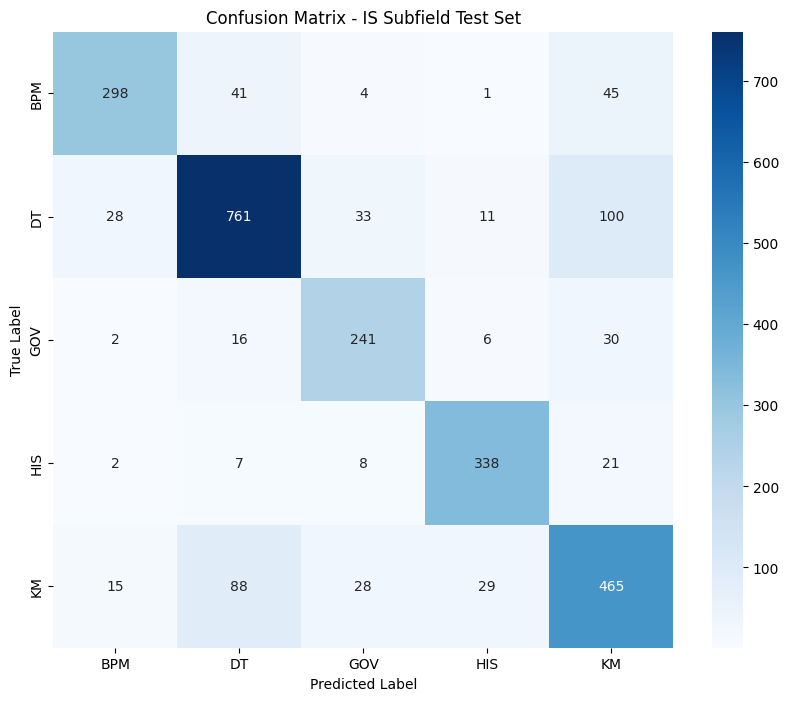


BPM accuracy: 0.7661 (n=389)

DT accuracy: 0.8156 (n=933)

GOV accuracy: 0.8169 (n=295)

HIS accuracy: 0.8989 (n=376)

KM accuracy: 0.7440 (n=625)


In [22]:
# Evaluate best model on test set
test_pred = best_model.predict(X_test_features)
test_pred_proba = best_model.predict_proba(X_test_features)

# Get predictions in original labels
test_pred_labels = label_encoder.inverse_transform(test_pred)

# Calculate metrics
test_accuracy = accuracy_score(y_test, test_pred_labels)
print(f"Test set accuracy: {test_accuracy:.4f}")

# Detailed classification report
print(f"\nClassification Report for {DISCIPLINE} Subfields:")
print(classification_report(y_test, test_pred_labels))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {DISCIPLINE} Subfield Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Per-class accuracy
for i, class_name in enumerate(label_encoder.classes_):
    class_mask = y_test == class_name
    if class_mask.sum() > 0:
        class_acc = accuracy_score(y_test[class_mask], test_pred_labels[class_mask])
        print(f"\n{class_name} accuracy: {class_acc:.4f} (n={class_mask.sum()})")

In [23]:
# Analyze misclassifications
misclassified_mask = y_test != test_pred_labels
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassifications: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_test)*100:.2f}%)")

# Confusion analysis
confusion_pairs = Counter(zip(y_test[misclassified_mask], test_pred_labels[misclassified_mask]))
print(f"\nMost common confusions for {DISCIPLINE} subfields (true_label -> predicted_label):")
for (true_label, pred_label), count in confusion_pairs.most_common(5):
    print(f"{true_label} -> {pred_label}: {count} times")

# Sample misclassified examples
print("\nSample misclassified abstracts:")
if len(misclassified_indices) > 0:
    sample_indices = np.random.choice(misclassified_indices, min(3, len(misclassified_indices)), replace=False)
    for i in sample_indices:
        print(f"\nTrue: {y_test[i]}, Predicted: {test_pred_labels[i]}")
        print(f"Confidence: {test_pred_proba[i].max():.3f}")
        print(f"Text preview: {X_test[i][:200]}...")

Total misclassifications: 515 (19.67%)

Most common confusions for IS subfields (true_label -> predicted_label):
DT -> KM: 100 times
KM -> DT: 88 times
BPM -> KM: 45 times
BPM -> DT: 41 times
DT -> GOV: 33 times

Sample misclassified abstracts:

True: HIS, Predicted: GOV
Confidence: 0.632
Text preview: us emergency legal responses to novel coronavirus this viewpoint discusses the policy and legal ramifications of the national public health emergency declared by the us government in response the coro...

True: KM, Predicted: BPM
Confidence: 0.375
Text preview: mission and strategy of the compliance program of metallurgical enterprise development management the authors analyze the peculiarities of the macro- and micro-environment in the conditionsof martial ...

True: BPM, Predicted: KM
Confidence: 0.557
Text preview: sales funnel a marketing analytic tool the article is dedicated to determining the practical value of the principles of building such a marketing tool instrument as a sales

In [24]:
class SubfieldClassifierPipeline:
    """Production-ready pipeline for subfield classification"""

    def __init__(self, discipline):
        self.discipline = discipline
        self.feature_extractor = None
        self.model = None
        self.label_encoder = None
        self.is_fitted = False

    def fit(self, X, y):
        """Train the complete pipeline"""
        # Initialize components
        self.feature_extractor = OptimizedFeatureExtractor()
        self.label_encoder = LabelEncoder()

        # Encode labels
        y_encoded = self.label_encoder.fit_transform(y)

        # Extract features
        X_features = self.feature_extractor.fit_transform(X)

        # Train model
        self.model = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            objective='multi:softprob',
            n_jobs=-1,
            random_state=RANDOM_SEED
        )
        self.model.fit(X_features, y_encoded)

        self.is_fitted = True
        return self

    def predict(self, X):
        """Predict subfields for new texts"""
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted first")

        # Extract features
        X_features = self.feature_extractor.transform(X)

        # Predict
        predictions = self.model.predict(X_features)

        # Convert to labels
        return self.label_encoder.inverse_transform(predictions)

    def predict_proba(self, X):
        """Get prediction probabilities"""
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted first")

        X_features = self.feature_extractor.transform(X)
        proba = self.model.predict_proba(X_features)

        # Return as dictionary with class labels
        results = []
        for p in proba:
            result = {}
            for i, class_label in enumerate(self.label_encoder.classes_):
                result[class_label] = float(p[i])
            results.append(result)

        return results

    def classify_single(self, title, abstract):
        """Classify a single paper"""
        # Preprocess
        combined_text = f"{title} {abstract}"
        processed_text = preprocess_text(combined_text)

        # Predict
        prediction = self.predict([processed_text])[0]
        proba = self.predict_proba([processed_text])[0]

        return {
            'discipline': self.discipline,
            'subfield': prediction,
            'confidence': proba[prediction],
            'probabilities': proba
        }

    def save(self, path):
        """Save the pipeline"""
        joblib.dump({
            'discipline': self.discipline,
            'feature_extractor': self.feature_extractor,
            'model': self.model,
            'label_encoder': self.label_encoder
        }, path)

    def load(self, path):
        """Load a saved pipeline"""
        components = joblib.load(path)
        self.discipline = components['discipline']
        self.feature_extractor = components['feature_extractor']
        self.model = components['model']
        self.label_encoder = components['label_encoder']
        self.is_fitted = True
        return self

# Create and train production pipeline
print(f"Training {DISCIPLINE} subfield production pipeline...")
pipeline = SubfieldClassifierPipeline(DISCIPLINE)
pipeline.fit(X_train_aug, y_train_aug)

# Test examples based on discipline
if DISCIPLINE == 'CS':
    test_papers = [
        ("Deep Learning for Image Classification",
         "This paper presents a novel convolutional neural network architecture for classifying images..."),
        ("Blockchain Security Analysis",
         "We analyze the security properties of blockchain protocols and identify vulnerabilities..."),
        ("Natural Language Understanding with Transformers",
         "This work explores transformer models for semantic parsing and text comprehension...")
    ]
elif DISCIPLINE == 'IS':
    test_papers = [
        ("Digital Transformation in Healthcare",
         "A study of how hospitals implement electronic health records and digital systems..."),
        ("Knowledge Management Systems",
         "This research examines how organizations capture and share organizational knowledge..."),
        ("Business Process Automation",
         "We present a framework for automating business workflows using process mining...")
    ]
else:  # IT
    test_papers = [
        ("Cloud Migration Strategies",
         "Best practices for migrating enterprise applications to AWS and Azure cloud platforms..."),
        ("DevOps Pipeline Implementation",
         "Implementing CI/CD pipelines using Jenkins and Kubernetes for containerized applications..."),
        ("IoT Security in Smart Cities",
         "Analyzing security vulnerabilities in Internet of Things devices deployed in urban environments...")
    ]

print(f"\nTest classifications for {DISCIPLINE} papers:")
for title, abstract in test_papers:
    result = pipeline.classify_single(title, abstract)
    print(f"\nTitle: {title}")
    print(f"Predicted: {result['subfield']} (confidence: {result['confidence']:.3f})")

Training IS subfield production pipeline...

Test classifications for IS papers:

Title: Digital Transformation in Healthcare
Predicted: HIS (confidence: 0.649)

Title: Knowledge Management Systems
Predicted: KM (confidence: 0.973)

Title: Business Process Automation
Predicted: BPM (confidence: 0.994)


In [25]:
# Create artifacts directory
save_dir = f'{DISCIPLINE.lower()}_subfield_classifier_v7'
os.makedirs(save_dir, exist_ok=True)

# Save the production pipeline
pipeline_path = f'{save_dir}/{DISCIPLINE.lower()}_subfield_pipeline_v7.pkl'
pipeline.save(pipeline_path)
print(f"Pipeline saved to {pipeline_path}")

# Save individual components
artifacts = {
    'discipline': DISCIPLINE,
    'feature_extractor': feature_extractor,
    'model': best_model,
    'label_encoder': label_encoder,
    'training_config': {
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'augmentation_ratio': 0.5,
        'feature_count': X_train_features.shape[1],
        'best_model': best_model_name,
        'test_accuracy': test_accuracy,
        'cv_mean_accuracy': cv_scores.mean() if 'cv_scores' in locals() else None,
        'subfield_classes': label_encoder.classes_.tolist(),
        'timestamp': datetime.now().isoformat()
    }
}

joblib.dump(artifacts, f'{save_dir}/artifacts_v7.pkl')

# Save performance metrics
with open(f'{save_dir}/metrics_v7.txt', 'w') as f:
    f.write(f"{DISCIPLINE} Subfield Classifier v7.0 Performance Metrics\n")
    f.write(f"=" * 50 + "\n\n")
    f.write(f"Training date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Discipline: {DISCIPLINE}\n")
    f.write(f"Total {DISCIPLINE} papers: {len(df)}\n")
    f.write(f"Train/Val/Test split: {len(X_train)}/{len(X_val)}/{len(X_test)}\n")
    f.write(f"Augmented training size: {len(X_train_aug)}\n")
    f.write(f"Feature count: {X_train_features.shape[1]}\n")
    f.write(f"Best model: {best_model_name}\n")
    f.write(f"Subfield classes: {', '.join(label_encoder.classes_)}\n\n")
    if 'cv_scores' in locals():
        f.write(f"Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}\n")
    f.write(f"Test accuracy: {test_accuracy:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, test_pred_labels))

print("\nAll artifacts saved successfully!")
print(f"\nFinal test accuracy: {test_accuracy:.4f}")
if 'cv_scores' in locals():
    print(f"Expected production accuracy: {cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}")

Pipeline saved to is_subfield_classifier_v7/is_subfield_pipeline_v7.pkl

All artifacts saved successfully!

Final test accuracy: 0.8033
Expected production accuracy: 0.7684 ± 0.0225


In [26]:
# Save to Google Drive
!cp -r {save_dir} "/content/drive/MyDrive/"
print(f"✓ {DISCIPLINE} subfield classifier saved to Google Drive!")

# Create zip for download
import zipfile

zip_name = f'{DISCIPLINE.lower()}_subfield_classifier_v7.zip'
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for root, dirs, files_in_dir in os.walk(save_dir):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path)
            zipf.write(file_path, arcname)

# Download
from google.colab import files
files.download(zip_name)

print(f"\n✓ {DISCIPLINE} subfield classifier download started!")

✓ IS subfield classifier saved to Google Drive!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ IS subfield classifier download started!
